In [15]:
import pandas as pd                            # DataFrame operations
import numpy as np                             # Numerical computing
import matplotlib.pyplot as plt                # Visualization
import seaborn as sns                          # Statistical plots
from sklearn.svm import SVC                    # Support Vector Classifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time
from matplotlib.colors import LinearSegmentedColormap

In [4]:
df = pd.read_csv("Final_svm_preprocessed_data.csv")

In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [6]:
X_model, _, y_model, _ = train_test_split(
    X, y,
    train_size=50,
    stratify=y,
    random_state=42  # for reproducibility
)

In [7]:
# Use the same data for training and testing
x_train, y_train = X_model, y_model
x_test, y_test = X_model, y_model

In [9]:
kernel_params = {
    "linear": {
        "C": [0.1, 1, 10, 100, 1000, 10000]
    },
    "rbf": {
        "C": [0.1, 1, 10, 100, 1000],
        "gamma": [0.001, 0.01, 0.1, 1, 10]
    },
    "poly": {
        "C": [0.1, 1, 10, 100],
        "degree": [2, 3, 4, 5],
        "gamma": ['scale', 'auto']
    },
    "sigmoid": {
        "C": [0.1, 1, 10, 100],
        "gamma": ['scale', 'auto']
    }
}

In [26]:
def train_and_evaluate_svm(x_train, y_train, x_test, y_test, kernel_params):
    best_svm_models = {}
    kernel_times = {}

    # Create directory to save confusion matrices if it doesn't exist
    os.makedirs("confusion_matrices_same_datas", exist_ok=True)

    for kernel_name, param_grid in kernel_params.items():
        print(f"\n Training SVM with kernel: {kernel_name.upper()}")
        
        model = SVC(kernel=kernel_name)
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring="accuracy",
            cv=5,
            verbose=1,
            n_jobs=-1
        )

        start_time = time.time()
        grid.fit(x_train, y_train)
        elapsed_time = time.time() - start_time

        best_model = grid.best_estimator_
        best_svm_models[kernel_name] = best_model
        kernel_times[kernel_name] = elapsed_time

        y_pred = best_model.predict(x_test)

        print(f" Best parameters for {kernel_name}: {grid.best_params_}")
        print("\n Classification Report:")
        print(classification_report(y_test, y_pred))
        
        acc = accuracy_score(y_test, y_pred)
        print(f" Accuracy Score: {acc:.8f}")
        print(f" Training Time: {elapsed_time:.4f} seconds")

        # === Confusion Matrix ===
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=True)
        plt.title(f"Confusion Matrix - {kernel_name.upper()} Kernel")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()

        # Save confusion matrix plot
        filename = f"confusion_matrices_same_datas/confusion_matrix_{kernel_name}.png"
        plt.savefig(filename)
        print(f" Confusion matrix saved to: {filename}")
        plt.show()

    print("\n Training Time Summary:")
    for k, v in kernel_times.items():
        print(f"- {k.upper()} kernel: {v:.4f} seconds")

    return best_svm_models



 Training SVM with kernel: LINEAR
Fitting 5 folds for each of 6 candidates, totalling 30 fits
 Best parameters for linear: {'C': 0.1}

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        22

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

 Accuracy Score: 1.00000000
 Training Time: 1.7514 seconds
 Confusion matrix saved to: confusion_matrices_same_datas/confusion_matrix_linear.png


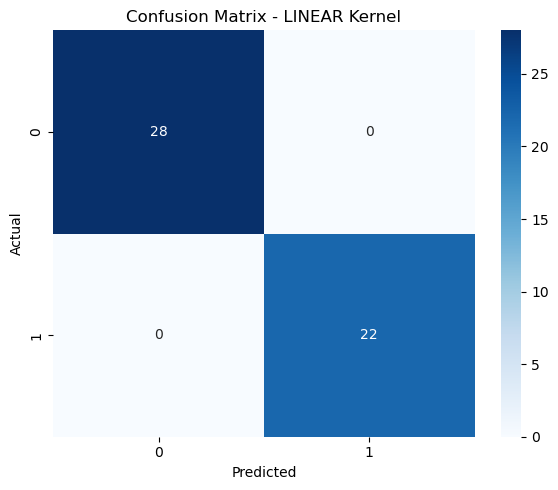


 Training SVM with kernel: RBF
Fitting 5 folds for each of 25 candidates, totalling 125 fits
 Best parameters for rbf: {'C': 10, 'gamma': 0.01}

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        22

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

 Accuracy Score: 1.00000000
 Training Time: 2.6758 seconds
 Confusion matrix saved to: confusion_matrices_same_datas/confusion_matrix_rbf.png


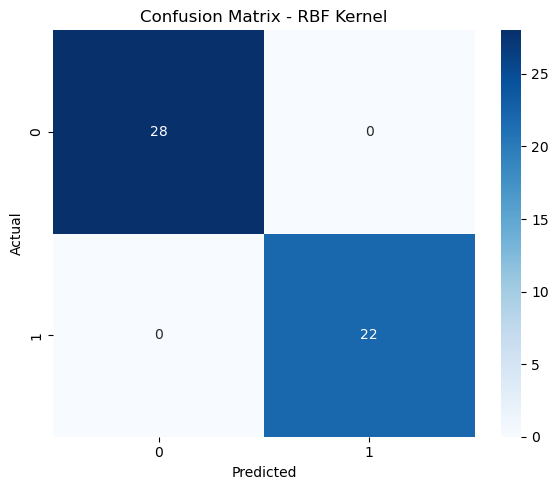


 Training SVM with kernel: POLY
Fitting 5 folds for each of 32 candidates, totalling 160 fits
 Best parameters for poly: {'C': 1, 'degree': 3, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        22

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

 Accuracy Score: 1.00000000
 Training Time: 2.3784 seconds
 Confusion matrix saved to: confusion_matrices_same_datas/confusion_matrix_poly.png


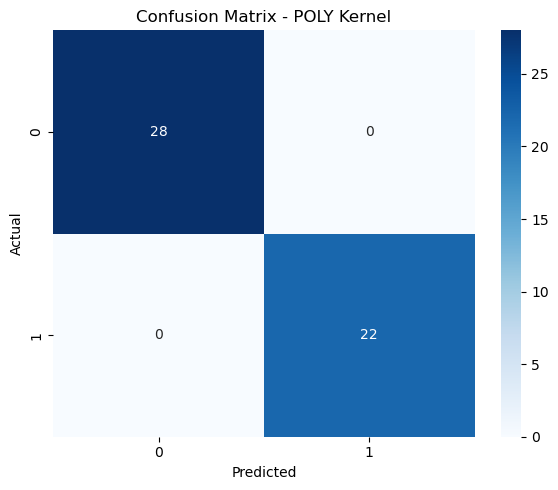


 Training SVM with kernel: SIGMOID
Fitting 5 folds for each of 8 candidates, totalling 40 fits
 Best parameters for sigmoid: {'C': 1, 'gamma': 'auto'}

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        22

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

 Accuracy Score: 1.00000000
 Training Time: 0.8307 seconds
 Confusion matrix saved to: confusion_matrices_same_datas/confusion_matrix_sigmoid.png


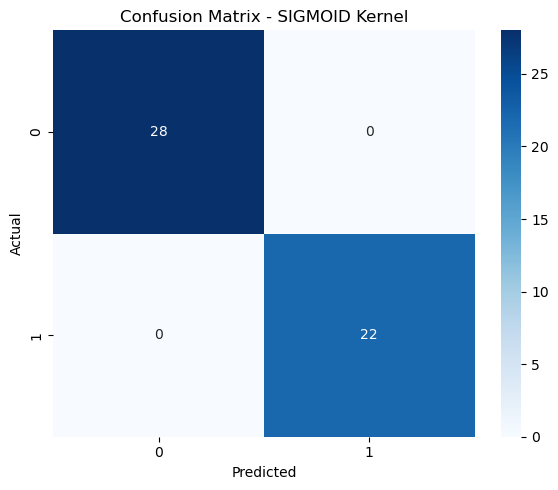


 Training Time Summary:
- LINEAR kernel: 1.7514 seconds
- RBF kernel: 2.6758 seconds
- POLY kernel: 2.3784 seconds
- SIGMOID kernel: 0.8307 seconds


In [27]:
best_models = train_and_evaluate_svm(x_train, y_train, x_test, y_test, kernel_params)

In [30]:
# Get indices of those 50 samples
indices_50 = X_model.index

In [21]:
# Exclude these 50 indices from full data to get remaining dataset
X_remaining = X.drop(indices_50)
y_remaining = y.drop(indices_50)

In [22]:
# Now, take 100 samples from remaining data with stratify
X_100, _, y_100, _ = train_test_split(
    X_remaining, y_remaining, train_size=100, stratify=y_remaining, random_state=42
)


 Training SVM with kernel: LINEAR
Fitting 5 folds for each of 6 candidates, totalling 30 fits
 Best parameters for linear: {'C': 1}

 Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.96      0.98        45

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

 Accuracy Score: 0.98000000
 Training Time: 0.7756 seconds
 Confusion matrix saved to: confusion_matrices_same_datas/confusion_matrix_linear.png


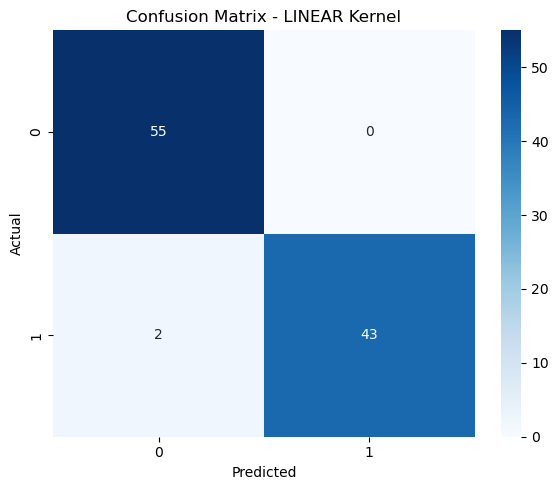


 Training SVM with kernel: RBF
Fitting 5 folds for each of 25 candidates, totalling 125 fits
 Best parameters for rbf: {'C': 100, 'gamma': 0.01}

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        55
           1       1.00      0.98      0.99        45

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

 Accuracy Score: 0.99000000
 Training Time: 1.7749 seconds
 Confusion matrix saved to: confusion_matrices_same_datas/confusion_matrix_rbf.png


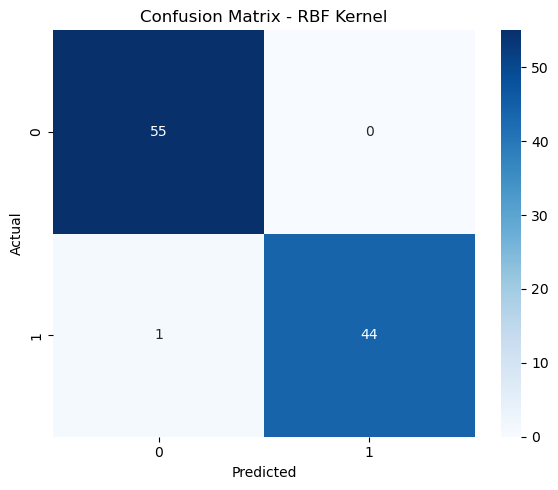


 Training SVM with kernel: POLY
Fitting 5 folds for each of 32 candidates, totalling 160 fits
 Best parameters for poly: {'C': 10, 'degree': 3, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.96      0.98        45

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

 Accuracy Score: 0.98000000
 Training Time: 1.7653 seconds
 Confusion matrix saved to: confusion_matrices_same_datas/confusion_matrix_poly.png


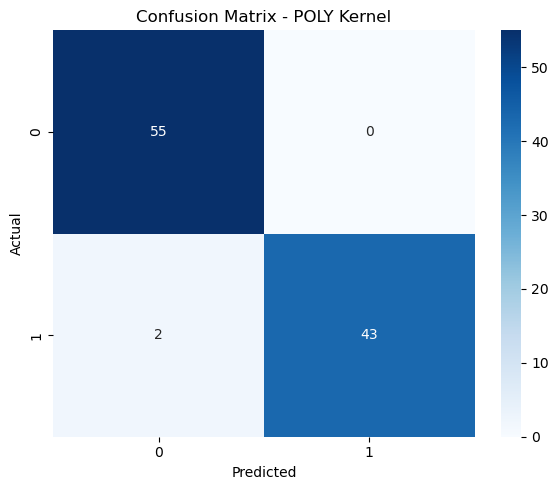


 Training SVM with kernel: SIGMOID
Fitting 5 folds for each of 8 candidates, totalling 40 fits
 Best parameters for sigmoid: {'C': 0.1, 'gamma': 'scale'}

 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96        55
           1       0.98      0.91      0.94        45

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100

 Accuracy Score: 0.95000000
 Training Time: 0.4844 seconds
 Confusion matrix saved to: confusion_matrices_same_datas/confusion_matrix_sigmoid.png


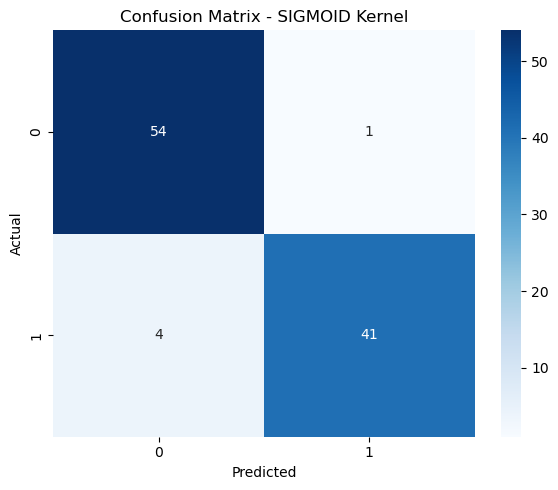


 Training Time Summary:
- LINEAR kernel: 0.7756 seconds
- RBF kernel: 1.7749 seconds
- POLY kernel: 1.7653 seconds
- SIGMOID kernel: 0.4844 seconds


{'linear': SVC(C=1, kernel='linear'),
 'rbf': SVC(C=100, gamma=0.01),
 'poly': SVC(C=10, kernel='poly'),
 'sigmoid': SVC(C=0.1, kernel='sigmoid')}

In [28]:
# Use the same data for training and testing, as you specified
train_and_evaluate_svm(X_100, y_100, X_100, y_100, kernel_params)

In [39]:
#Combiner les indices déjà utilisés (50 + 100)
used_indices = indices_50.append(X_100.index)  # même logique

In [40]:
#Supprimer ces indices du DataFrame complet
X_remaining_300 = X.drop(used_indices)
y_remaining_300 = y.drop(used_indices)


In [41]:
#Sélectionner 300 nouvelles images à partir des données restantes
X_300, _, y_300, _ = train_test_split(
    X_remaining_300, y_remaining_300,
    train_size=300,
    stratify=y_remaining_300,
    random_state=42
)

In [ ]:
train_and_evaluate_svm(X_300, y_300, X_300, y_300, kernel_params)